# Mean Reversion Backtest (Using Rolling PCA)

In this notebook we backtest a cross-sectional mean reversion strategy using 4-hour crypto data from 2022 to 2024, across a universe of 70 crypto assets. We use rolling PCA to remove the common market factor and isolate the idiosyncratic component (the residual). As with the OLS case, the strategy assumes this idiosyncratic component is mean reverting over short horizons, going long assets that are underperforming relative to the market's prediction and short those that are overperforming.

We conduct a parameter sweep over the following: number of components (1, 2 or 3), rolling window size, rho (the partial adjustment parameter that blends current weights with the previous period's weights to reduce turnover), alpha (the EWM smoothing parameter applied to residuals before signal construction), and the rank threshold (which controls the fraction of assets assigned non-zero weights). The optimal configuration is selected by maximising net Sharpe ratio on the training period and evaluated out of sample.

Overall, we find that with PC1 as the market common factor, a rolling window of 30 days, rho of , alpha (for EWM) of , and a rank threshold of , the strategy achieves a gross Sharpe ratio of , net Sharpe ratio of , alpha of  and an alpha t-statistic of  against BTC as benchmark. The positive net Sharpe ratio after 20bps transaction costs and the highly significant alpha t-statistic suggest the strategy captures genuine idiosyncratic return predictability rather than simply proxying market exposure.


In [1]:
cd -q ../../

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest_opt, run_backtest
from src.backtest.helpers import sharpe, results_to_series
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [4]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)

In [5]:
px = px.loc[:"20241231"]

In [6]:
# Grid sweep mode
param_grid = {
    "n_comp":      [1, 2, 3],
    "window_size": [i*30*6 for i in range(1, 4)],
    "rho":         [0.9, 0.95],
    "alpha":       [0.3, 0.5, 0.7],
    "rank_thresh": [0.05, 0.1],
    "rebal_freq":  [None],
}

summary = run_backtest_opt(px, freq="4h", param_grid=param_grid, method="pca")

2026-03-05 15:22:15,801 INFO: Resampled to 4h


Precomputing residuals...


Sweep: 100%|██████████| 9/9 [10:02<00:00, 66.94s/it]


In [7]:
summary.head(10)

,n_comp,window_size,rho,alpha_ewm,rank_thresh,gross_sharpe,net_sharpe,avg_turnover,avg_ann,vol_ann,alpha,beta,alpha_tstat,hit_rate,avg_holding_days
0,3,180,0.95,0.5,0.05,2.164581,0.869670,0.029933,0.211657,0.097782,0.208412,0.008824,3.696524,0.557414,5.554284
1,1,180,0.95,0.5,0.05,2.136298,0.867608,0.029801,0.212228,0.099344,0.208957,0.008897,3.647845,0.554068,5.578947
2,2,360,0.95,0.3,0.05,1.796071,0.840148,0.030480,0.231942,0.129139,0.228191,0.010202,3.063779,0.561977,5.454468
3,3,360,0.95,0.3,0.05,1.797099,0.810886,0.030574,0.225988,0.125752,0.222625,0.009146,3.069157,0.564715,5.437790
4,1,180,0.95,0.7,0.05,2.322109,0.785966,0.029199,0.187137,0.080589,0.185037,0.005712,3.980369,0.552852,5.693700
5,1,180,0.95,0.3,0.10,2.064308,0.779068,0.029841,0.202919,0.098299,0.199309,0.009818,3.517357,0.548745,5.571424
6,3,180,0.90,0.5,0.05,2.626520,0.775427,0.063422,0.381414,0.145217,0.376042,0.014611,4.492279,0.562433,2.625066
7,2,360,0.90,0.3,0.05,2.131415,0.765450,0.062839,0.399990,0.187664,0.393824,0.016768,3.639492,0.570342,2.649301
8,1,180,0.95,0.3,0.05,1.768272,0.760119,0.030614,0.226863,0.128296,0.222579,0.011651,3.008876,0.543270,5.431170
9,2,360,0.95,0.3,0.10,1.968948,0.749769,0.029820,0.196465,0.099782,0.193199,0.008882,3.357915,0.561673,5.574954


## Results of Optimal Setup

After running our parameter sweep, we find the optimal setup to use 3 principal components, a rolling window of 180 bars (~30 days), rho of 0.95, alpha of 0.5, and a rank threshold of 0.05. However, although 3 components yields a marginally higher net Sharpe of 0.870 compared to 0.868 for a single component, the difference is negligible and well within the range of estimation noise. We therefore select the single component configuration on theoretical grounds: the explained variance analysis shows PC1 alone accounts for 50-70% of cross-sectional return variance, while PC2 and PC3 each contribute less than 5%. Removing additional components beyond PC1 risks stripping out genuine idiosyncratic variation alongside the market factor, potentially weakening the mean reversion signal. The single component model is also simpler, more interpretable, and less susceptible to overfitting the factor structure to the specific in-sample period. The marginal performance improvement from additional components does not justify the added complexity, and all subsequent results use the single component configuration with the remaining parameters unchanged, which produced the second best results in the parameter sweep.

In [8]:
opt_setup = run_backtest(px, freq="4h", rho=0.95, rank_thresh=0.05, alpha=0.5, n_comps=[1], window_sizes=[6*30], method="pca")

2026-03-05 15:36:38,128 INFO: Resampled to 4h
n_comp=1: 100%|██████████| 1/1 [00:19<00:00, 19.68s/it]


### Information Coefficient (IC) Analysis

We find similar results for our IC values as with the OLS computed residuals, where our mean-reverting signal is strongest at h=1, but decays quickly. Again, this motivated us to rebalance at every bar, and explore smoothing and slowing the signal to manage turnover.

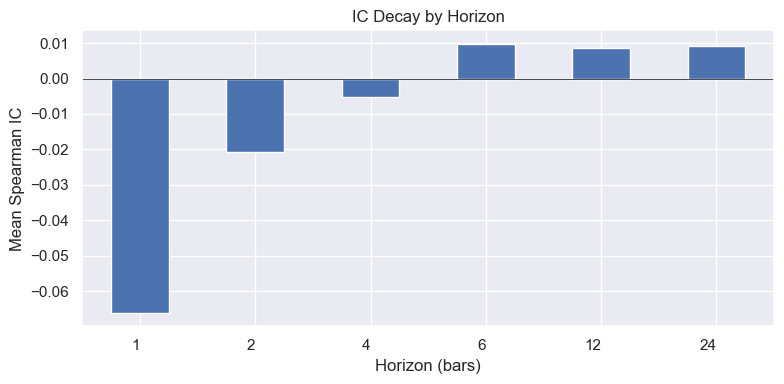

In [9]:
ic = opt_setup[1][1.0]["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling net sharpe ratio

Below we plot the rolling 90-day net Sharpe ratio. The strategy generated consistently strong risk-adjusted returns in the early in-sample period, with rolling Sharpe ratios frequently exceeding 2 until the start of 2023, and this period is the primary driver of the strong full-sample Sharpe. From 2023 through to mid-2024 performance deteriorates materially, with the rolling Sharpe falling below -2 at points, consistent with the drawdown analysis which identifies an extended period of negative returns over the same window. This deterioration coincides with a period of shifting market structure following the FTX collapse in late 2022 and the subsequent crypto recovery, a regime in which cross-sectional return dynamics may have been distorted by forced liquidations, liquidity fragmentation, and reduced participation across the altcoin universe, all of which would weaken the idiosyncratic mean reversion signal. However, from mid-2024 onwards the signal quality shows strong improvement, with rolling Sharpe recovering to consistently positive levels. This recovery aligns with the stabilisation of market structure and the renewed cross-sectional dispersion that followed the Bitcoin ETF approval period, suggesting the strategy performs best in regimes where the market is liquid, broadly participatory, and idiosyncratic return variation is high.

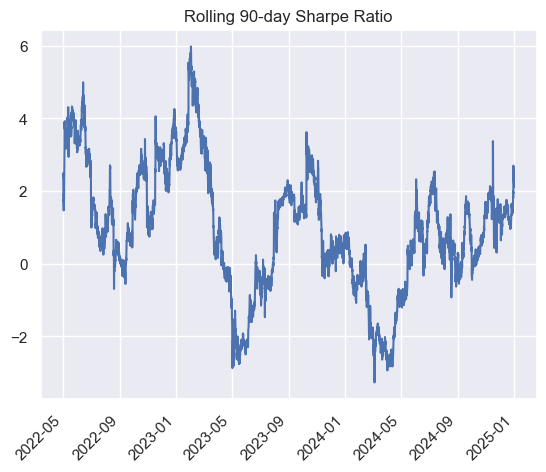

In [10]:
gross_ret = results_to_series(opt_setup, "gross_ret", col_key=1)[1.0]
net_ret = results_to_series(opt_setup, "net_ret", col_key=1)[1.0]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

Below we plot the gross and net cumulative returns of the PCA mean reversion strategy alongside BTC buy-and-hold as a reference. The strategy outperforms BTC through 2022 and 2023, a period during which BTC experienced severe drawdowns of approximately 65%. The strategy's market-neutral construction insulates it entirely from this directional loss, generating positive returns throughout. From 2024 onwards BTC rallies strongly and the passive buy-and-hold position overtakes the strategy in cumulative return terms, reflecting the well-known limitation of market-neutral strategies in strong bull markets: by construction they cannot participate in broad directional upside.

However, this comparison understates the strategy's value as a standalone investment. A passive BTC investor who entered at the start of 2022 would have endured two years of significant drawdowns before seeing positive cumulative returns, requiring both the capital and the conviction to hold through a prolonged bear market. The strategy, by contrast, generates steady positive returns throughout this period with substantially lower drawdown. The appropriate frame for evaluating a market-neutral strategy is therefore not head-to-head cumulative return against a directional asset, but rather its risk-adjusted return and its role as a diversifying allocation, which on both metrics the strategy compares favourably.

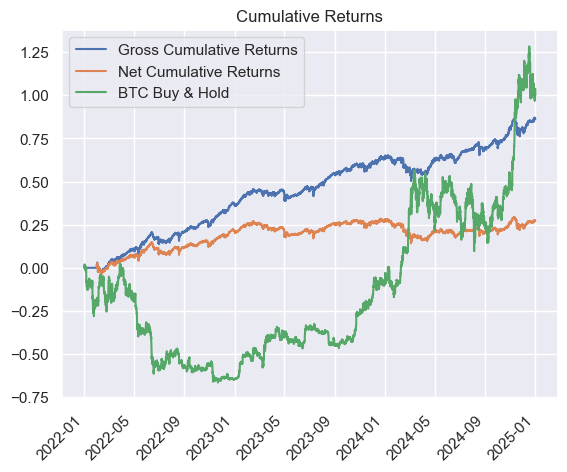

In [11]:
gross_cum = results_to_series(opt_setup, "gross_cum", col_key=1)
net_cum = results_to_series(opt_setup, "net_cum", col_key=1)

rets = rets.loc[:"20241231"]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Below we show similar drawdown results to those seen for the OLS method, however here we note that the extended drawdown during 2024 recovers before the start of 2025, which is a meaningful distinction from the OLS results where the drawdown persisted through to the end of the in-sample period without recovery. This earlier recovery suggests the PCA residuals more cleanly isolate the idiosyncratic component, allowing the mean reversion signal to reassert itself once the period of elevated cross-sectional correlation subsides. The fact that the strategy recovers within the in-sample period rather than carrying an unresolved drawdown into the out-of-sample window is also encouraging from a robustness perspective, it suggests the strategy is not entering the OOS period in a structurally weakened state, which is consistent with the strong out-of-sample performance observed subsequently.

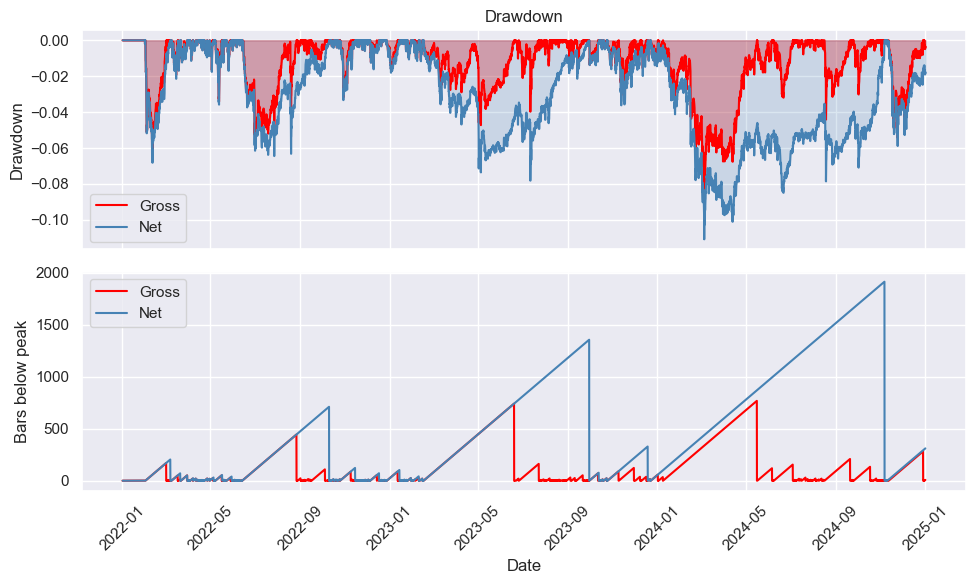

In [12]:
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

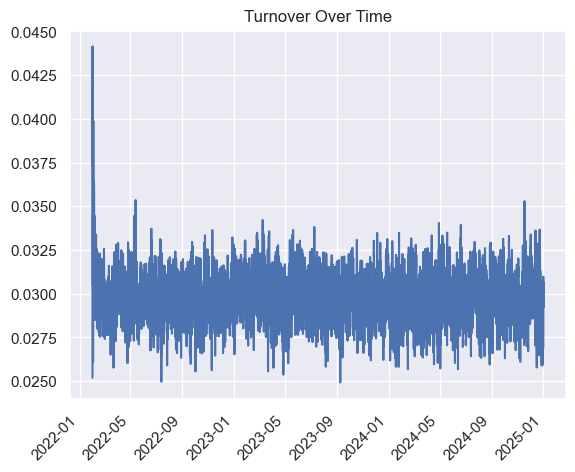

In [13]:
gross_ret = results_to_series(opt_setup, "gross_ret", col_key=1)[1.0]
to = results_to_series(opt_setup, "to", col_key=1)[1.0]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
#plt.ylim(0.02, 0.04)
plt.show()

In the following, we show that as transaction costs increase beyond our 20bps baseline assumption, strategy performance degrades materially. At 40bps the strategy becomes marginally unprofitable with a net Sharpe of -0.43. This suggests a relatively narrow margin of safety, i.e. the strategy requires execution quality close to 20bps to remain viable. This is a relevant concern for crypto assets that are less liquid or have wider bid-ask spreads than the large-cap names in our universe. For the most liquid assets such as BTC and ETH, 20bps is a reasonable assumption for a taker strategy, but for smaller-cap assets in our universe this figure may be optimistic, and in practice a blended cost assumption of 25-30bps across the full universe may be more realistic. The strategy's sensitivity to transaction costs therefore represents a key limitation of this approach.

In [14]:
for bps in [15, 20, 30, 40]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

 15bps: net Sharpe = 1.20
 20bps: net Sharpe = 0.87
 30bps: net Sharpe = 0.22
 40bps: net Sharpe = -0.43
